# 信号延迟买入与延长持仓参数化研究

研究目标：探索延迟1-5天买入、持仓延长1-2天的效果

策略核心逻辑：
- 延长期内只判断止损（12%），其他卖出条件忽略
- 延长期结束后恢复正常卖出逻辑（大幅低开、未涨停、最后卖出）

In [1]:
%reload_ext autoreload
%autoreload 2
from my_utils.fun import *
from my_utils.trade_fun import *
import polars as pl
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

logging = get_logger(log_file='log/延迟参数研究.log', inherit=False)

【软件终端连接成功！】
【账户信息订阅成功！】


In [2]:
# 读取信号文件（复用法回测demo.ipynb的信号生成逻辑）

start_date = dt.date(2025, 1, 1)
end_date = dt.datetime.today()

# 获取指定日期的日线数据
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='gm_stock_all_data')
stock_data = stock_data.with_columns([
   (pl.col('mv_A_free_float') / 1e8).alias('mv_A_free_float'),
   (pl.col('total_mv') / 1e8).alias('total_mv')
])

In [3]:
# 信号生成特征计算（与回测demo.ipynb一致）
# 1.涨停标记
stock_data = mark_limit_status(stock_data)
stock_data = mark_limit_desc(stock_data)
stock_data = mark_last_limit_desc(stock_data)
stock_data = cal_limit_avg_turnover(stock_data, window=5, turnover_col='turnover_rate')

# 2.均线特征
stock_data = add_sma(stock_data, window=5)
stock_data = add_sma(stock_data, window=7)

# 3.计算开盘涨幅、乖离率、成交均价vwap
stock_data = stock_data.with_columns([
    ((pl.col("open") - pl.col("pre_close")) / pl.col("pre_close") * 100).alias("open_pct"),
    ((pl.col("close") - pl.col("sma_7")) / pl.col("sma_7") * 100).alias("close_sma7_pct"),
    (pl.col("amount") * 100 / pl.col("volume")).alias("vwap"),
    ((pl.col("low") <= pl.col("limit_down") * 1.01)).alias("touch_limit_down"),
    (pl.col("close") / pl.col("pre_close") - 1).alias("pct")
])
stock_data = cal_n_lowest(stock_data)

# 4.排序并添加移位特征
stock_data = stock_data.sort(["code", "trading_date"])
stock_data = stock_data.with_columns([
    pl.col("limit_status").shift(1).over("code").alias("prev_limit_status"),
    pl.col("sma_7").shift(1).over("code").alias("prev_sma_7"),
    pl.col("pct").shift(1).over("code").alias("pre_pct"),
    pl.col("vwap").shift(1).over("code").alias("pre_vwap"),
    pl.col("close_sma7_pct").shift(1).over("code").alias("pre_close_sma7_pct"),
])

In [4]:
# 5.信号筛选条件
params_dict = {
    'low': -5,
    'high': -2.5,
    'mv_min': 35,
    'mv_max': 1000,
    'prev_limit_status': ['断板', '炸板'],
    'avg_limit_turnover_5_min': -1
}

stock_data = stock_data.with_columns(
    signal = pl.when(
        ~(pl.col("is_st")) &
        ~(pl.col("code").str.split(".").list[1].str.starts_with("30") | 
          pl.col("code").str.split(".").list[1].str.starts_with("688") |
            pl.col("code").str.split(".").list[1].str.starts_with("90") |
            pl.col("code").str.split(".").list[1].str.starts_with("20")   ) &
        (pl.col("prev_limit_status").is_in(params_dict['prev_limit_status'])) &
        (pl.col("open_pct") >= params_dict["low"]) & 
        (pl.col("open_pct") <= params_dict["high"]) &
        (pl.col("pre_close") >= pl.col("prev_sma_7")) &
        (pl.col("last_limit_desc") != "1天1板") &
        (pl.col("last_limit_desc").is_not_null()) &
        (pl.col("mv_A_free_float") >= params_dict["mv_min"]) & 
        (pl.col("mv_A_free_float") <= params_dict["mv_max"]) &
        ((pl.col("open") / pl.col("lowest_30")) <= 3)
    ).then(1).otherwise(0)
)

信号文件 = stock_data.filter(pl.col("signal") == 1)
logging.info(f"信号参数: {params_dict}")
logging.info(f"信号数量: {len(信号文件)}")

信号参数: {'low': -5, 'high': -2.5, 'mv_min': 35, 'mv_max': 1000, 'prev_limit_status': ['断板', '炸板'], 'avg_limit_turnover_5_min': -1}
信号数量: 1161


In [5]:
# 参数化回测循环
from itertools import product

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

delay_range = [0, 1, 2, 3, 4, 5]  # 延迟1-5天
extend_range = [0, 1, 2]          # 持仓延长0-2天

# 存储结果
results_matrix = []

for delay, extend in product(delay_range, extend_range):
    logging.info(f"运行参数组合: buy_delay={delay}, extend={extend}")
    
    # 调用回测（注意：默认止损已改为12%）
    result_df, merged_df = cal_trade_info(
        信号文件, 
        trade_fun=trade,
        start_date=start_date_str, 
        end_date=end_date_str,
        buy_delay_days=delay,
        extend_holding_days=extend
    )
    
    # 只取有盈利的记录计算指标（排除未触发卖出的）
    valid_df = merged_df.filter(pl.col("profit").is_not_null())
    
    # 计算关键指标
    if len(valid_df) > 0:
        # 胜率
        win_rate = valid_df.filter(pl.col("profit") > 0).height / len(valid_df)
        
        # 平均收益
        avg_profit = valid_df['profit'].mean()
        
        # 盈亏比
        win_df = valid_df.filter(pl.col("profit") > 0)
        loss_df = valid_df.filter(pl.col("profit") < 0)
        avg_win = win_df['profit'].mean() if len(win_df) > 0 else 0
        avg_loss = abs(loss_df['profit'].mean()) if len(loss_df) > 0 else 0
        profit_loss_ratio = avg_win / avg_loss if avg_loss > 0 else float('inf')
        
        # 平均持仓天数
        avg_holding_days = valid_df['holding_days'].mean()
        
        # 交易数量
        trade_count = len(valid_df)
        
        # 止损比例
        stop_loss_ratio = valid_df.filter(pl.col("sell_reason") == "止损卖出").height / len(valid_df)
        
        # 夏普比率 (基于每笔收益的波动率计算, 年化252交易日)
        profit_std = valid_df['profit'].std()
        sharpe_ratio = (avg_profit / profit_std) * np.sqrt(252 / avg_holding_days) if profit_std > 0 else 0
    else:
        win_rate = avg_profit = profit_loss_ratio = avg_holding_days = trade_count = stop_loss_ratio = sharpe_ratio = 0
    
    results_matrix.append({
        'buy_delay_days': delay,
        'extend_holding_days': extend,
        'trade_count': trade_count,
        'win_rate': win_rate,
        'avg_profit': avg_profit,
        'profit_loss_ratio': profit_loss_ratio,
        'avg_holding_days': avg_holding_days,
        'stop_loss_ratio': stop_loss_ratio,
        'sharpe_ratio': sharpe_ratio
    })
    
    logging.info(f"  交易数量: {trade_count}, 胜率: {win_rate:.2%}, 平均收益: {avg_profit:.2f}%, 盈亏比: {profit_loss_ratio:.2f}, 夏普: {sharpe_ratio:.3f}")

运行参数组合: buy_delay=0, extend=0
使用40个进程并行处理，共298个日期任务
回测任务进度: 100%|███████████████████████| 298/298 [00:10<00:00, 28.93个日期/s]
所有回测任务完成，共处理298个日期的结果
  交易数量: 1161, 胜率: 42.81%, 平均收益: 0.43%, 盈亏比: 1.47, 夏普: 0.463
运行参数组合: buy_delay=0, extend=1
使用40个进程并行处理，共298个日期任务
回测任务进度: 100%|███████████████████████| 298/298 [00:10<00:00, 29.20个日期/s]
所有回测任务完成，共处理298个日期的结果
  交易数量: 1161, 胜率: 41.26%, 平均收益: 0.21%, 盈亏比: 1.49, 夏普: 0.167
运行参数组合: buy_delay=0, extend=2
使用40个进程并行处理，共298个日期任务
回测任务进度: 100%|███████████████████████| 298/298 [00:09<00:00, 31.02个日期/s]
所有回测任务完成，共处理298个日期的结果
  交易数量: 1161, 胜率: 39.79%, 平均收益: -0.09%, 盈亏比: 1.49, 夏普: -0.061
运行参数组合: buy_delay=1, extend=0
使用40个进程并行处理，共298个日期任务
回测任务进度:  96%|█████████████████████▉ | 285/298 [00:09<00:00, 64.42个日期/s]SHSE.600770在2026-04-28日买入延迟1天超出可用交易日，跳过该股票
SHSE.603060在2026-04-28日买入延迟1天超出可用交易日，跳过该股票
SHSE.603618在2026-04-28日买入延迟1天超出可用交易日，跳过该股票
回测任务进度: 100%|███████████████████████| 298/298 [00:09<00:00, 30.01个日期/s]
所有回测任务完成，共处理297个日期的结果
  交易数量: 1158, 胜率: 37.65%, 平均收益: -0

In [6]:
# 结果汇总为DataFrame并展示热力图
results_df = pd.DataFrame(results_matrix)
print(results_df.to_string(index=False))

 buy_delay_days  extend_holding_days  trade_count   win_rate  avg_profit  profit_loss_ratio  avg_holding_days  stop_loss_ratio  sharpe_ratio
              0                    0         1161 0.42807924  0.42786652         1.47442182        1.59991387       0.08440999    0.46252799
              0                    1         1161 0.41257537  0.21190698         1.48819845        2.46856158       0.14470284    0.16705666
              0                    2         1161 0.39793282 -0.09319632         1.48552218        3.24849268       0.19035314   -0.06062866
              1                    0         1158 0.37651123 -0.88751449         1.34641279        1.43264249       0.13644214   -1.04618845
              1                    1         1158 0.36010363 -1.25886112         1.35138355        2.25345423       0.18998273   -1.10811976
              1                    2         1158 0.35233161 -1.55774327         1.33035987        3.03238342       0.22107081   -1.11340052
             

In [7]:
# 绘制热力图对比
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 转为透视表格式
metrics = ['win_rate', 'avg_profit', 'profit_loss_ratio', 'sharpe_ratio']
fig = make_subplots(rows=2, cols=2, subplot_titles=metrics)

for i, metric in enumerate(metrics):
    row = i // 2 + 1
    col = i % 2 + 1
    
    pivot_df = results_df.pivot(index='buy_delay_days', columns='extend_holding_days', values=metric)
    fig.add_trace(
        go.Heatmap(
            x=pivot_df.columns,
            y=pivot_df.index,
            z=pivot_df.values,
            colorscale='RdYlGn',
            text=np.round(pivot_df.values, 3),
            texttemplate='%{text}',
            textfont={"size": 10},
            showscale=False
        ),
        row=row, col=col
    )
    fig.update_xaxes(title_text='extend_holding_days', row=row, col=col)
    fig.update_yaxes(title_text='buy_delay_days', row=row, col=col)

fig.update_layout(title_text='延迟买入与延长持仓参数研究结果', height=800)
fig.show()

In [8]:
# 保存结果
results_df.to_csv('log/延迟参数研究结果.csv', index=False, encoding='utf-8-sig')
logging.info('结果已保存到 log/延迟参数研究结果.csv')

结果已保存到 log/延迟参数研究结果.csv


C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 24310 (\N{CJK UNIFIED IDEOGRAPH-5EF6}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 36831 (\N{CJK UNIFIED IDEOGRAPH-8FDF}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 32988 (\N{CJK UNIFIED IDEOGRAPH-80DC}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\ipykernel_3060\2454450426.py:28: UserWarning:

Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.

C:\Users\20561\AppData\Local\Temp\

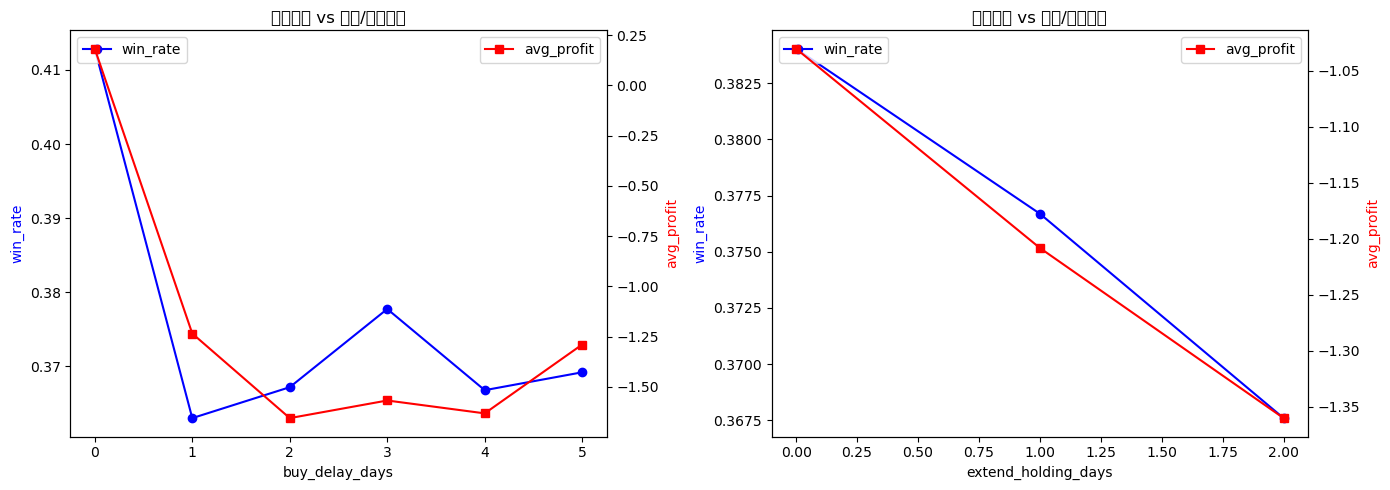

In [9]:
# 可视化：单独分析延迟天数对胜率/收益率的影响
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按延迟天数聚合
delay_group = results_df.groupby('buy_delay_days')[['win_rate', 'avg_profit']].mean()
axes[0].plot(delay_group.index, delay_group['win_rate'], 'b-o', label='win_rate')
axes[0].set_xlabel('buy_delay_days')
axes[0].set_ylabel('win_rate', color='b')
ax2 = axes[0].twinx()
ax2.plot(delay_group.index, delay_group['avg_profit'], 'r-s', label='avg_profit')
ax2.set_ylabel('avg_profit', color='r')
axes[0].set_title('延迟天数 vs 胜率/平均收益')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# 按延长天数聚合
extend_group = results_df.groupby('extend_holding_days')[['win_rate', 'avg_profit']].mean()
axes[1].plot(extend_group.index, extend_group['win_rate'], 'b-o', label='win_rate')
axes[1].set_xlabel('extend_holding_days')
axes[1].set_ylabel('win_rate', color='b')
ax2 = axes[1].twinx()
ax2.plot(extend_group.index, extend_group['avg_profit'], 'r-s', label='avg_profit')
ax2.set_ylabel('avg_profit', color='r')
axes[1].set_title('延长天数 vs 胜率/平均收益')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()